# Intro

1. Для каких из уже изученных моделей актуально проклятие размерности и объясните почему.

Оно актуально, например, для KNN, где каждый дополнительный вектор данных вносит шум и точность вычисления соседей сильно падает. Т.е. актуальна для любого алгоритма, который основан на вычислении дистанций.

2. В чем разница между PCA и SVD?

PCA - Principal Component Analysis - алгоритм уменьшения размерности данных через PC, а SVD - Singular Vector Decomposition - более общее математическое разложение любой прямоугольной матрицы на 3 подматрицы, раскладывая ее на ортогональные векторы и сингулярные числа. В некоторых случаях PCA эквивалентен применению SVD к центрированной матрице.

3. В чем разница между NMF и SVD?

NMF - Non-Negative Matrix Factorization - работает строго с неотрицательными числами, тогда как SVD работает как с положительными, так и отрицательными значениями. По своей сути - отличие заключается в применении, например NMF логичнее использовать, когда данные строго неотрицательные, например RGB-представления цветов.

4. Cтруктура алгоритма уменьшения размерности локально-линейного вложения.

Выбрать k лучших соседей для каждой точки, найти лучшее представление каждой точки в виде комбинации ее соседей с точки зрения погрешности, ввести такое же количество низкоразмерных векторов, предполагая, что сохраняем те же связи с соседями, что и в исходных точках. Для поиска низкоразмерных векторов нужно использовать методы линейной алгебры.

# Introduction

In [18]:
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import optuna
from optuna.pruners import MedianPruner
from sklearn.decomposition import TruncatedSVD, PCA
from umap import UMAP

from urllib.request import urlretrieve
import os
import matplotlib.pyplot as plt
import gzip
from sklearn.manifold import TSNE, LocallyLinearEmbedding
import seaborn as sns

import cv2
from sklearn.utils.extmath import randomized_svd

import joblib

import os
from sklearn.preprocessing import StandardScaler

In [21]:
df1 = pd.read_csv("data/Ratings.csv")
df1

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6
...,...,...,...
1149775,276704,1563526298,9
1149776,276706,0679447156,0
1149777,276709,0515107662,10
1149778,276721,0590442449,10


In [22]:
df2 = pd.read_csv("data/Users.csv")
df2

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN
...,...,...,...
278853,278854,"portland, oregon, usa",NaN
278854,278855,"tacoma, washington, united kingdom",50.0
278855,278856,"brampton, ontario, canada",NaN
278856,278857,"knoxville, tennessee, usa",NaN


In [23]:
df = df1.merge(df2, 'inner')
df

,User-ID,ISBN,Book-Rating,Location,Age
0,276725,034545104X,0,"tyler, texas, usa",NaN
1,276726,0155061224,5,"seattle, washington, usa",NaN
2,276727,0446520802,0,"h, new south wales, australia",16.0
3,276729,052165615X,3,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,"rijeka, n/a, croatia",16.0
...,...,...,...,...,...
1149775,276704,1563526298,9,"cedar park, texas, usa",NaN
1149776,276706,0679447156,0,"quebec, quebec, canada",18.0
1149777,276709,0515107662,10,"mannington, west virginia, usa",38.0
1149778,276721,0590442449,10,"providence, rhode island, usa",14.0


In [24]:
df = df[df["Age"].notnull()]
df["Age"] = df["Age"].astype(int)

In [25]:
df

,User-ID,ISBN,Book-Rating,Location,Age
2,276727,0446520802,0,"h, new south wales, australia",16
3,276729,052165615X,3,"rijeka, n/a, croatia",16
4,276729,0521795028,6,"rijeka, n/a, croatia",16
5,276733,2080674722,0,"paris, n/a, france",37
7,276737,0600570967,6,"sydney, new south wales, australia",14
...,...,...,...,...,...
1149758,276697,8445072897,0,"oviedo, asturias, spain",29
1149776,276706,0679447156,0,"quebec, quebec, canada",18
1149777,276709,0515107662,10,"mannington, west virginia, usa",38
1149778,276721,0590442449,10,"providence, rhode island, usa",14


In [26]:
user_idxs = df["User-ID"].unique()
books_idxs = df["ISBN"].unique()
user_to_idxs = {user_id: idx for idx, user_id in enumerate(user_idxs)}
book_to_idxs = {book_id: idx for idx, book_id in enumerate(books_idxs)}

rows = df["User-ID"].map(user_to_idxs)
cols = df["ISBN"].map(book_to_idxs)

sparse_matrix = csr_matrix((df["Book-Rating"], (rows, cols)), shape=(len(user_idxs), len(books_idxs)))

sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 840288 stored elements and shape (62107, 285089)>

In [27]:
dense_matrix = pd.DataFrame.sparse.from_spmatrix(sparse_matrix)
dense_matrix.iloc[0:10, 0:20]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,3,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,10,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,9,0,0,9,8,7,0,7,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8,0,0,0
8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0
9,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,10,0


In [28]:
y = (
    df
    .groupby("User-ID")["Age"]
    .median()
    .loc[user_idxs]
    .values
)

y

array([16., 16., 37., ..., 38., 14., 12.], shape=(62107,))

In [29]:
X = sparse_matrix
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 840288 stored elements and shape (62107, 285089)>

In [30]:
print(X.shape)
print(y.shape)

(62107, 285089)
(62107,)


In [31]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.5, random_state=21)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, train_size=0.5, random_state=21)

In [32]:
def metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    
    print(f"R2: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")

In [33]:
linear_reg = LinearRegression()

linear_reg.fit(X_train, y_train)
print("Linear_reg(train):", end=" ")
metrics(y_train, linear_reg.predict(X_train))

Linear_reg(train): R2: 0.694, MAE: 3.983, RMSE: 8.156


In [34]:
print("Linear_reg(valid):", end=" ")
metrics(y_valid, linear_reg.predict(X_valid))

Linear_reg(valid): R2: -1.749, MAE: 15.214, RMSE: 24.344


In [35]:
np.random.seed(21)

In [36]:
def objective(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 250, step=10)
    max_depth = trial.suggest_int("max_depth", 3, 11, step=1)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10, step=1)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10, step=1)
    
    sample_size = 3000
    indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
    X_sample = X_train[indices].toarray()
    y_sample = y_train[indices]
    
    valid_size = 2000
    valid_indices = np.random.choice(X_valid.shape[0], valid_size, replace=False)
    X_valid_sample = X_valid[valid_indices].toarray()
    y_valid_sample = y_valid[valid_indices]
    
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        criterion="absolute_error",
        max_depth=max_depth,
        max_features="sqrt",
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=21
    )
    
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X_valid_sample)
    mae = mean_absolute_error(y_valid_sample, y_pred)
    
    return mae

study = optuna.create_study(direction="minimize", pruner=MedianPruner())
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
print(best_params)

[I 2026-08-29 17:43:34,022] A new study created in memory with name: no-name-2d668bd2-ee6e-4300-aeb1-f2a1ff86a49d


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-08-29 17:43:59,894] Trial 0 finished with value: 11.735479545454545 and parameters: {'n_estimators': 110, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 8}. Best is trial 0 with value: 11.735479545454545.
[I 2026-08-29 17:44:31,082] Trial 1 finished with value: 11.059010869565217 and parameters: {'n_estimators': 230, 'max_depth': 9, 'min_samples_split': 9, 'min_samples_leaf': 4}. Best is trial 1 with value: 11.059010869565217.
[I 2026-08-29 17:45:17,185] Trial 2 finished with value: 11.12953522727273 and parameters: {'n_estimators': 220, 'max_depth': 10, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 1 with value: 11.059010869565217.
[I 2026-08-29 17:45:45,720] Trial 3 finished with value: 10.80432794117647 and parameters: {'n_estimators': 170, 'max_depth': 10, 'min_samples_split': 3, 'min_samples_leaf': 3}. Best is trial 3 with value: 10.80432794117647.
[I 2026-08-29 17:46:08,752] Trial 4 finished with value: 11.4599125 and parameters: {'n_estimato

In [37]:
random_for = RandomForestRegressor(
        **best_params,
        random_state = 21
)

sample_size = 3000
indices = np.random.choice(X_train.shape[0], sample_size, replace=False)
X_sample = X_train[indices].toarray()
y_sample = y_train[indices]

random_for.fit(X_sample, y_sample)

print("Random_forest(train):", end=" ")
metrics(y_sample, random_for.predict(X_sample))

Random_forest(train): R2: 0.027, MAE: 11.304, RMSE: 14.244


In [38]:
# valid_size = 2000
# valid_indices = np.random.choice(X_valid.shape[0], valid_size, replace=False)
# X_valid_sample = X_valid[valid_indices].toarray()
# y_valid_sample = y_valid[valid_indices]

print("Random_forest(valid):", end=" ")
metrics(y_valid, random_for.predict(X_valid))

Random_forest(valid): R2: -0.001, MAE: 11.436, RMSE: 14.686


In [39]:
pca = PCA(n_components=2, random_state=21)

X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

print(X_train_pca.shape)
print(X_valid_pca.shape)
print(X_test_pca.shape)

(31053, 2)
(15527, 2)
(15527, 2)


In [40]:
umap_model = UMAP(n_components=2, random_state=21)

X_train_umap = umap_model.fit_transform(X_train)
X_valid_umap = umap_model.transform(X_valid)
X_test_umap = umap_model.transform(X_test)

print(X_train_umap.shape)
print(X_valid_umap.shape)
print(X_test_umap.shape)

/home/futrel/python314/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(31053, 2)
(15527, 2)
(15527, 2)


In [41]:
%%time
random_for.fit(X_train_pca, y_train)
metrics(y_valid, random_for.predict(X_valid_pca))

R2: 0.009, MAE: 11.388, RMSE: 14.617
CPU times: user 4.25 s, sys: 0 ns, total: 4.25 s
Wall time: 4.26 s


In [42]:
%%time
random_for.fit(X_train_umap, y_train)
metrics(y_valid, random_for.predict(X_valid_umap))

R2: 0.002, MAE: 11.465, RMSE: 14.666
CPU times: user 7.11 s, sys: 15.6 ms, total: 7.12 s
Wall time: 7.13 s


In [43]:
mask_train = ~np.isnan(X_train_umap).any(axis=1)
X_train_umap_clean = X_train_umap[mask_train]
y_train_clean = y_train[mask_train]

mask_valid = ~np.isnan(X_valid_umap).any(axis=1)
X_valid_umap_clean = X_valid_umap[mask_valid]
y_valid_clean = y_valid[mask_valid]

In [44]:
%%time
linear_reg.fit(X_train_pca, y_train)
metrics(y_valid, linear_reg.predict(X_valid_pca))

R2: -0.000, MAE: 11.478, RMSE: 14.682
CPU times: user 0 ns, sys: 0 ns, total: 0 ns
Wall time: 8.04 ms


In [45]:
%%time
linear_reg.fit(X_train_umap_clean, y_train_clean)
metrics(y_valid_clean, linear_reg.predict(X_valid_umap_clean))

R2: 0.000, MAE: 11.474, RMSE: 14.679
CPU times: user 15.6 ms, sys: 0 ns, total: 15.6 ms
Wall time: 12.2 ms


Качество RandomForest крайне незначительно улучшилось на PCA и чуть ухудшилось на UMAP.

Время обучения уменьшилось у тысячи раз.

Линейная модель все также дают R2 около 0, что подтверждает нелинейную зависимость.

## Visualizations

In [2]:
urls = {
    'train_images': 'https://ossci-datasets.s3.amazonaws.com/mnist/train-images-idx3-ubyte.gz',
    'train_labels': 'https://ossci-datasets.s3.amazonaws.com/mnist/train-labels-idx1-ubyte.gz',
    'test_images': 'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-images-idx3-ubyte.gz',
    'test_labels': 'https://ossci-datasets.s3.amazonaws.com/mnist/t10k-labels-idx1-ubyte.gz'
}

os.makedirs('data/mnist_data', exist_ok=True)

for name, url in urls.items():
    filename = f'data/mnist_data/{name}.gz'
    if not os.path.exists(filename):
        urlretrieve(url, filename)

In [3]:
def read_mnist_images(filename):
    with gzip.open(filename, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        num_images = int.from_bytes(f.read(4), 'big')
        rows = int.from_bytes(f.read(4), 'big')
        cols = int.from_bytes(f.read(4), 'big')
        
        data = f.read()
        images = np.frombuffer(data, dtype=np.uint8)
        images = images.reshape(num_images, rows * cols)
        return images

def read_mnist_labels(filename):
    with gzip.open(filename, 'rb') as f:
        magic = int.from_bytes(f.read(4), 'big')
        num_labels = int.from_bytes(f.read(4), 'big')
        
        data = f.read()
        labels = np.frombuffer(data, dtype=np.uint8)
        return labels

X_train = read_mnist_images('data/mnist_data/train_images.gz')
y_train = read_mnist_labels('data/mnist_data/train_labels.gz')
X_test = read_mnist_images('data/mnist_data/test_images.gz')
y_test = read_mnist_labels('data/mnist_data/test_labels.gz')

print(f"Train images: {X_train.shape}")
print(f"Train labels: {y_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

X_train = X_train / 255.0
X_test = X_test / 255.0

Train images: (60000, 784)
Train labels: (60000,)
Test images: (10000, 784)
Test labels: (10000,)


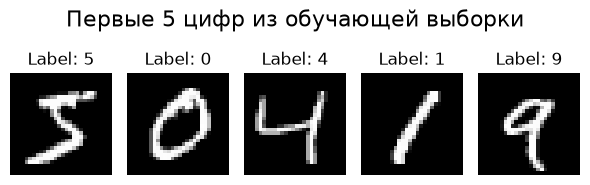

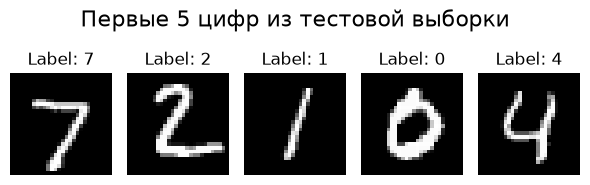

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(6, 2))
for i, ax in enumerate(axes.flat):
    img = X_train[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {int(y_train[i])}', fontsize=12)
    ax.axis('off')
plt.suptitle('Первые 5 цифр из обучающей выборки', fontsize=16)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 5, figsize=(6, 2))
for i, ax in enumerate(axes.flat):
    img = X_test[i].reshape(28, 28)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'Label: {int(y_test[i])}', fontsize=12)
    ax.axis('off')
plt.suptitle('Первые 5 цифр из тестовой выборки', fontsize=16)
plt.tight_layout()
plt.show()

In [5]:
def scatter_graph(X, y, title):
    plt.figure(figsize=(15, 8))
    
    sns.scatterplot(
        x = X[:, 0],
        y = X[:, 1],
        hue=y.astype(str),
        s=10,
        palette="tab10",
        alpha=0.5
    )
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.legend(title="Numbers", bbox_to_anchor=(1.05, 1), loc="upper left")


In [6]:
%%time
pca = PCA(n_components=2, random_state=21)
X_pca = pca.fit_transform(X_train)

explained_variance = pca.explained_variance_ratio_.sum()

print(f"Объясненная дисперсия:{explained_variance*100:.2f}%")

Объясненная дисперсия:16.80%
CPU times: user 11.6 s, sys: 609 ms, total: 12.2 s
Wall time: 1.13 s


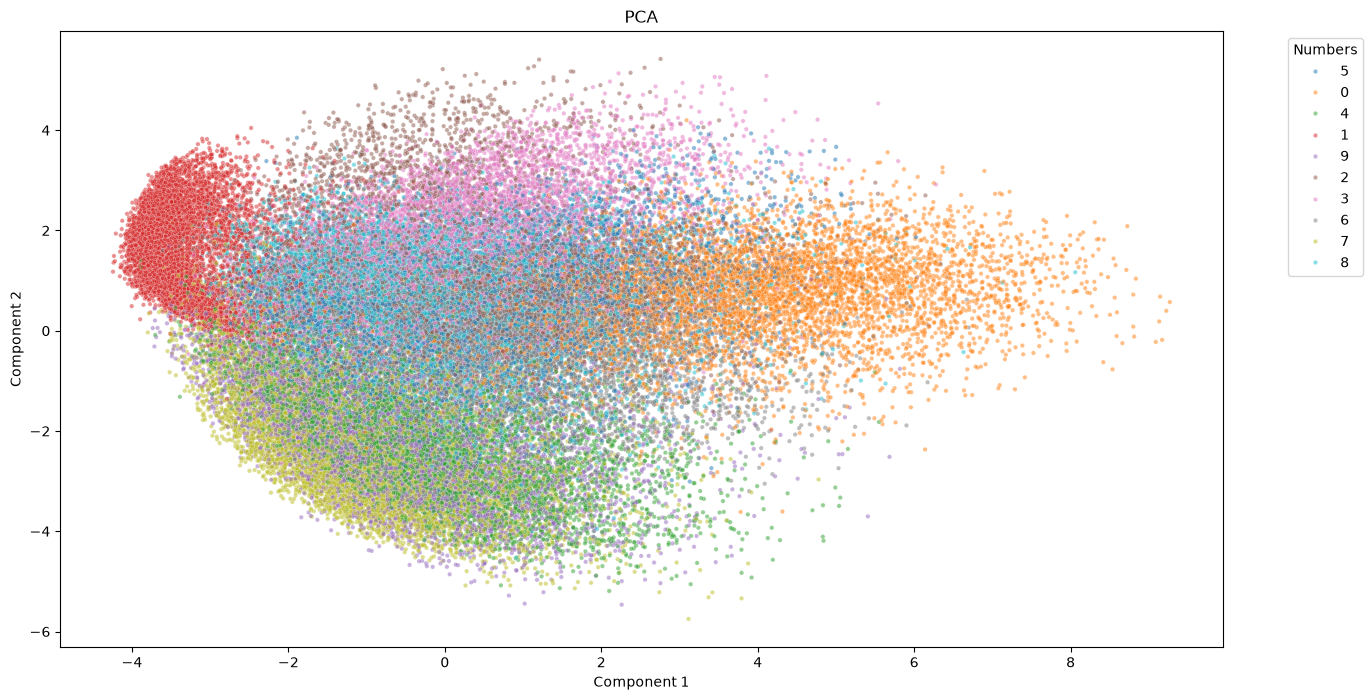

In [7]:
scatter_graph(X_pca, y_train, "PCA")

In [8]:
%%time
svd = TruncatedSVD(n_components=2, random_state=21)
X_svd = svd.fit_transform(X_train)

explained_variance_svd = svd.explained_variance_ratio_.sum()

print(f"Объясненная дисперсия:{explained_variance_svd*100:.2f}%")

Объясненная дисперсия:14.05%
CPU times: user 19 s, sys: 422 ms, total: 19.4 s
Wall time: 1.89 s


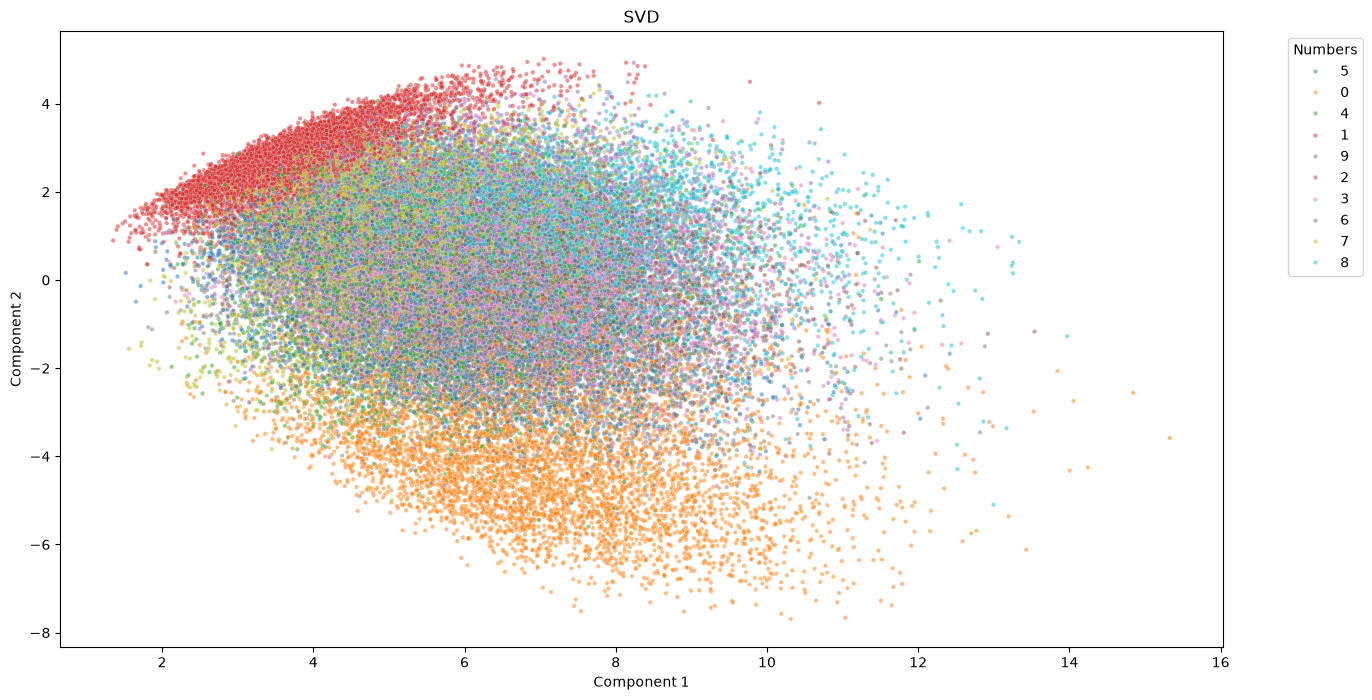

In [9]:
scatter_graph(X_svd, y_train, "SVD")

In [10]:
%%time
rsvd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=21, n_iter=5)
X_rsvd = rsvd.fit_transform(X_train)

explained_variance_rsvd = rsvd.explained_variance_ratio_.sum()

print(f"Объясненная дисперсия: {explained_variance_rsvd*100:.2f}%")

Объясненная дисперсия: 14.05%
CPU times: user 16.7 s, sys: 422 ms, total: 17.1 s
Wall time: 1.71 s


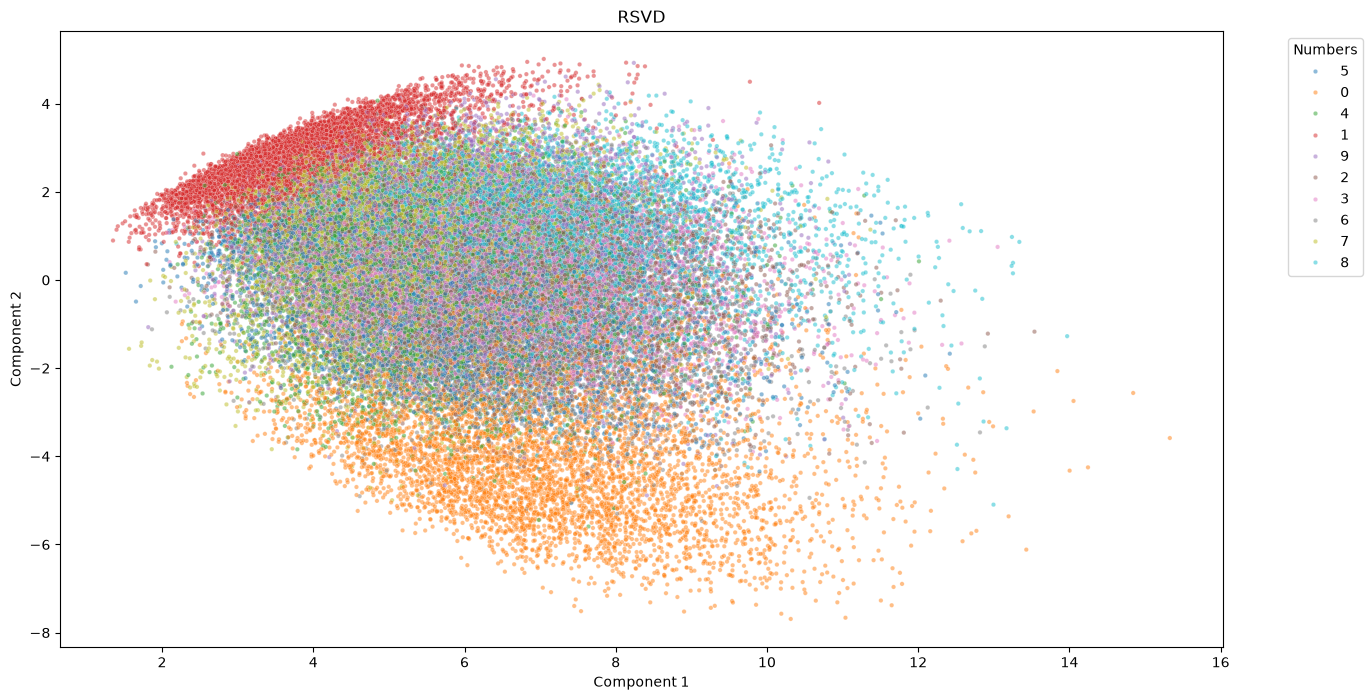

In [11]:
scatter_graph(X_rsvd, y_train, "RSVD")

In [12]:
%%time

tsne = TSNE(n_components=2, random_state=21, perplexity=30)
X_tsne = tsne.fit_transform(X_train)

CPU times: user 22min 3s, sys: 17.4 s, total: 22min 20s
Wall time: 4min 22s


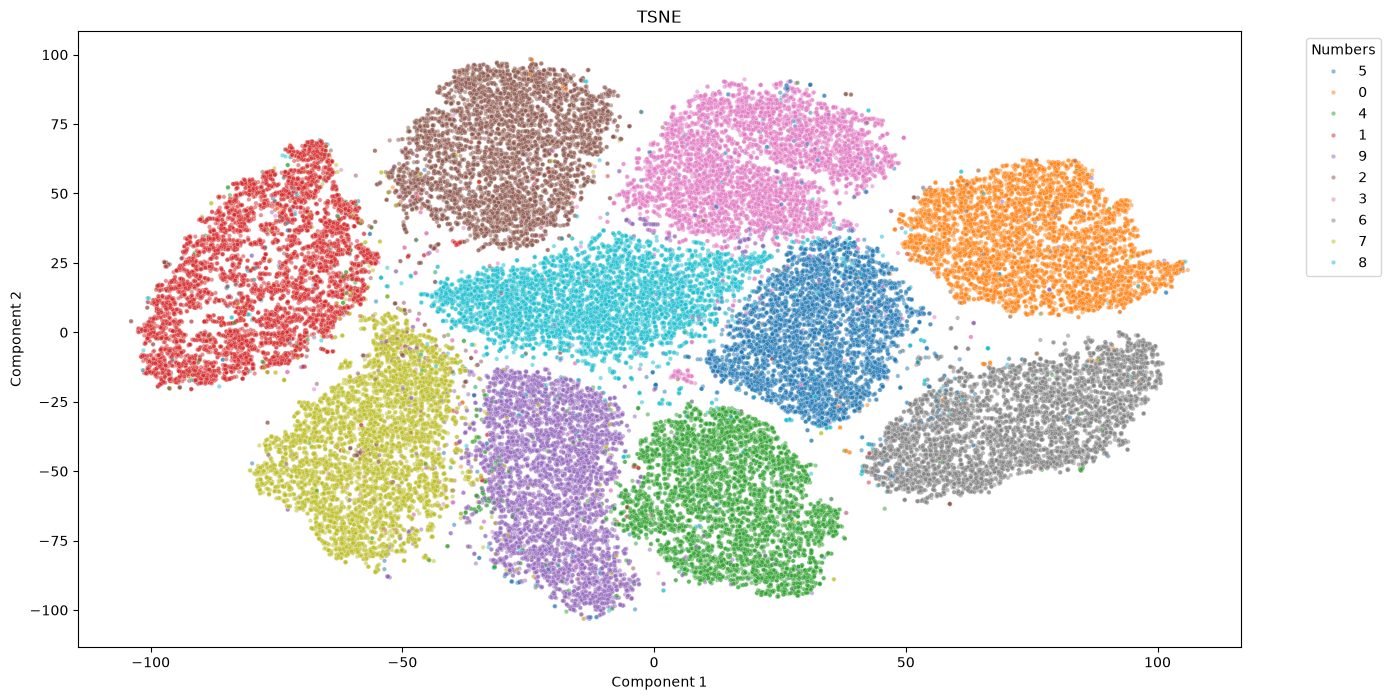

In [13]:
scatter_graph(X_tsne, y_train, "TSNE")

In [14]:
%%time
umap = UMAP(n_components=2, random_state=21)
X_umap = umap.fit_transform(X_train)

/home/futrel/python314/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: user 2min 23s, sys: 2.47 s, total: 2min 25s
Wall time: 1min 33s


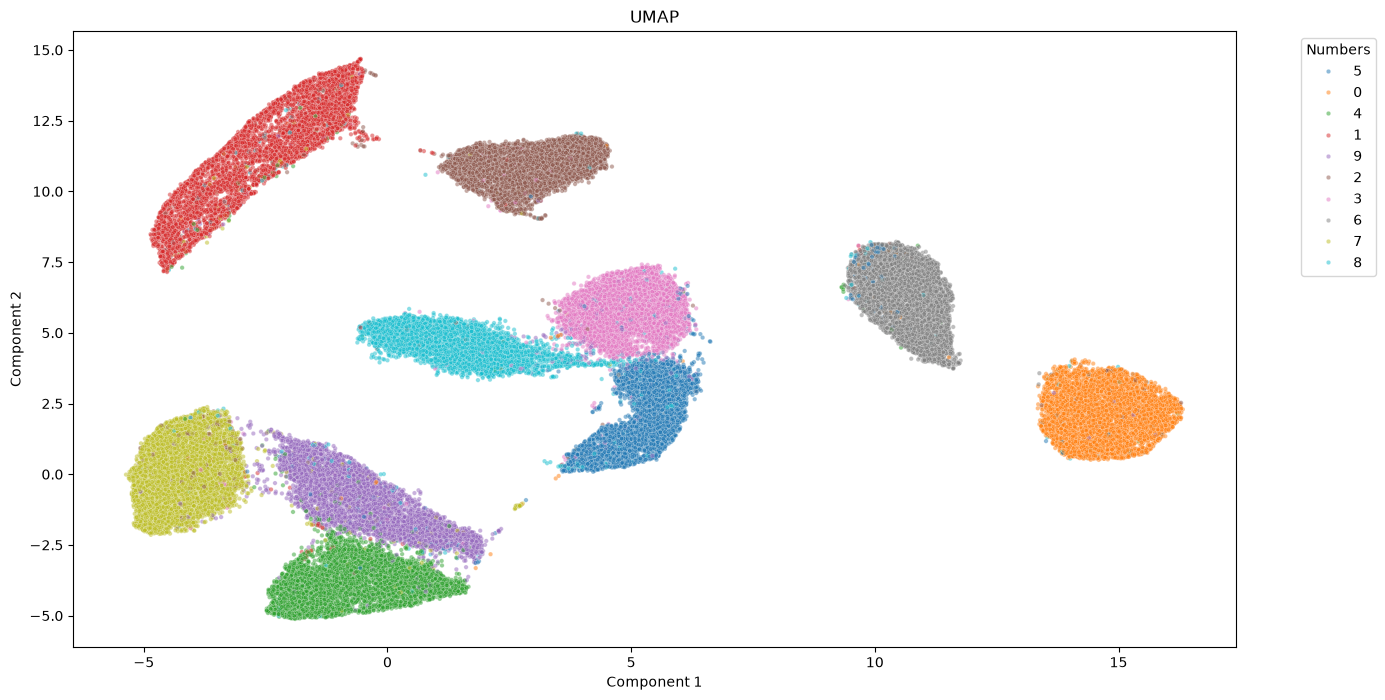

In [15]:
scatter_graph(X_umap, y_train, "UMAP")

In [16]:
%%time
SAMPLE_LLE = len(X_train) // 16
indices_lle = np.random.choice(len(X_train), SAMPLE_LLE, replace=False)
X_lle_sample = X_train[indices_lle]
y_lle_sample = y_train[indices_lle]

lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10, random_state=21)
X_lle = lle.fit_transform(X_lle_sample)

CPU times: user 5.42 s, sys: 78.1 ms, total: 5.5 s
Wall time: 4.48 s


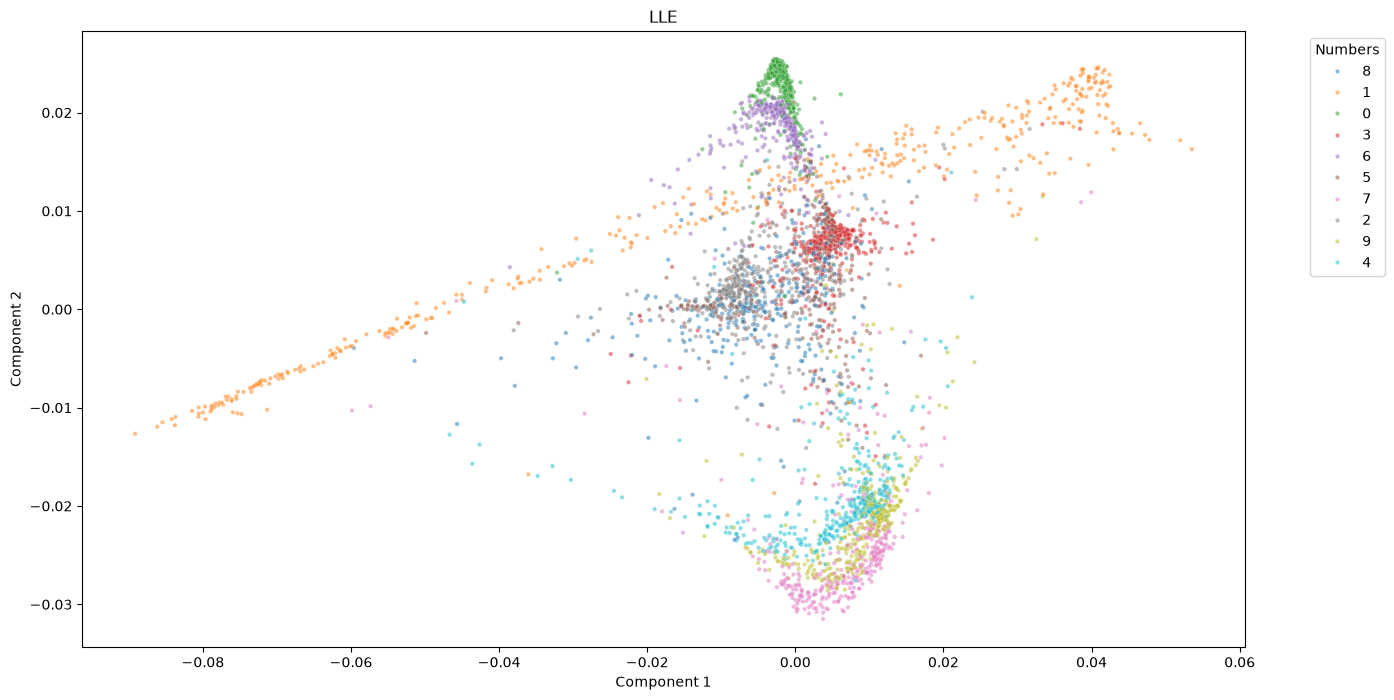

In [17]:
scatter_graph(X_lle, y_lle_sample, "LLE")

Видим наиболее точный результат на TSNE, но относительно большое время выполнения. На остальынх алгоритмах имеем примерно похожие резульаты и время выполнения. Время выполелнения LLE слишком велико, точность низкая

Loaded
Extracted


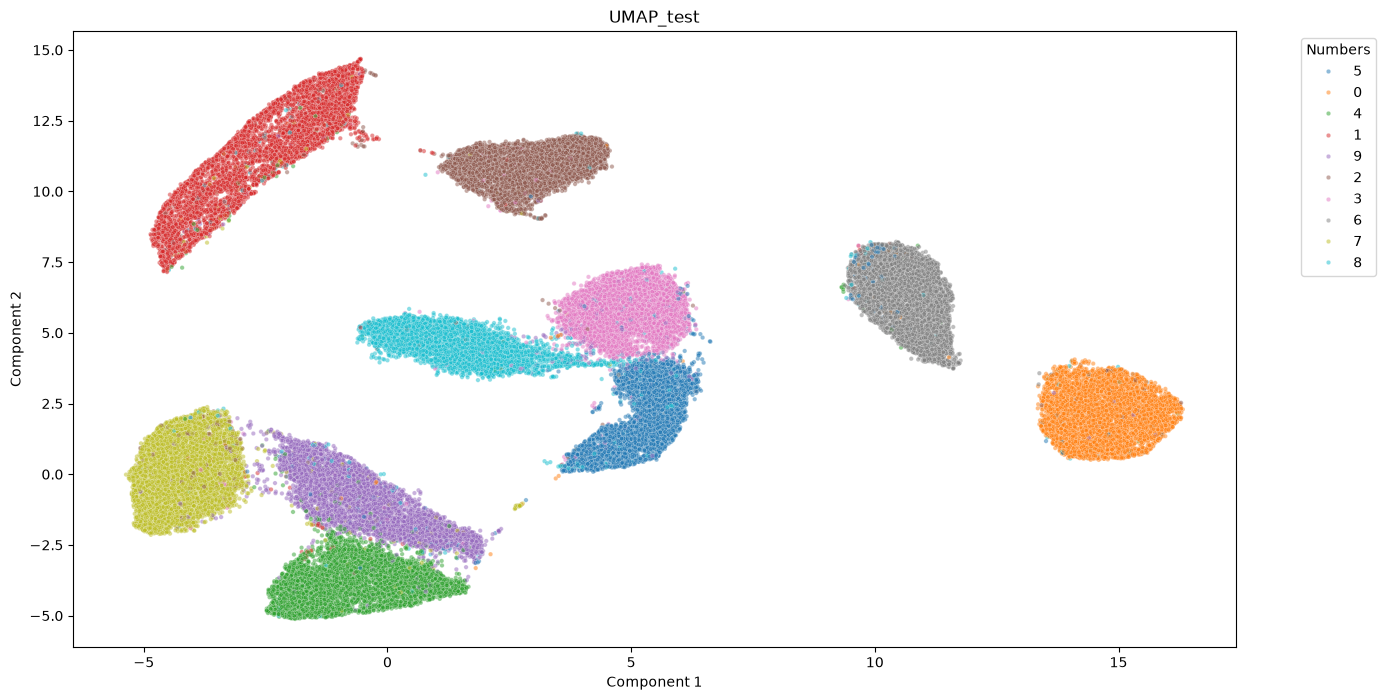

In [18]:
joblib.dump(umap, 'data/umap_model.joblib')
print("Loaded")
loaded_reducer = joblib.load('data/umap_model.joblib')
print("Extracted")

X_umap_test = loaded_reducer.transform(X_train)
scatter_graph(X_umap_test, y_train, "UMAP_test")

In [19]:
indices_tst = np.random.choice(len(X_train), 3, replace=False)
X_tst_sample = X_train[indices_tst]
y_tst_sample = y_train[indices_tst]

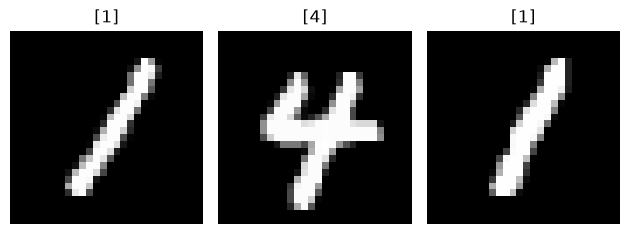

In [20]:
X_train_df = pd.DataFrame(X_train)

for i, idx in enumerate(indices_tst):
    digit = X_train_df.iloc[idx].values.reshape(28, 28)
    plt.subplot(1, len(indices_tst), i + 1)
    plt.imshow(digit, cmap="grey")
    plt.axis("off")
    plt.title(pd.DataFrame(y_train).iloc[idx].values)
    
plt.tight_layout()
plt.show()

In [21]:
def plot_rank_visual(image, U, S, VT, ranks):
    plt.figure(figsize=(2.2 * 11, 3))
    plt.subplot(1, 11, 1)
    plt.imshow(image, cmap='grey')
    plt.axis("off")
    plt.title("Orig")
    
    for i, rank in enumerate(ranks):
        image_ranked = U[:, :rank] @ np.diag(S[:rank]) @ VT[:rank, :]
        plt.subplot(1, 11, i + 2)
        plt.imshow(image_ranked, cmap='grey')
        plt.axis("off")
        plt.title(f"rank={rank}")
    
    plt.tight_layout()
    plt.show()


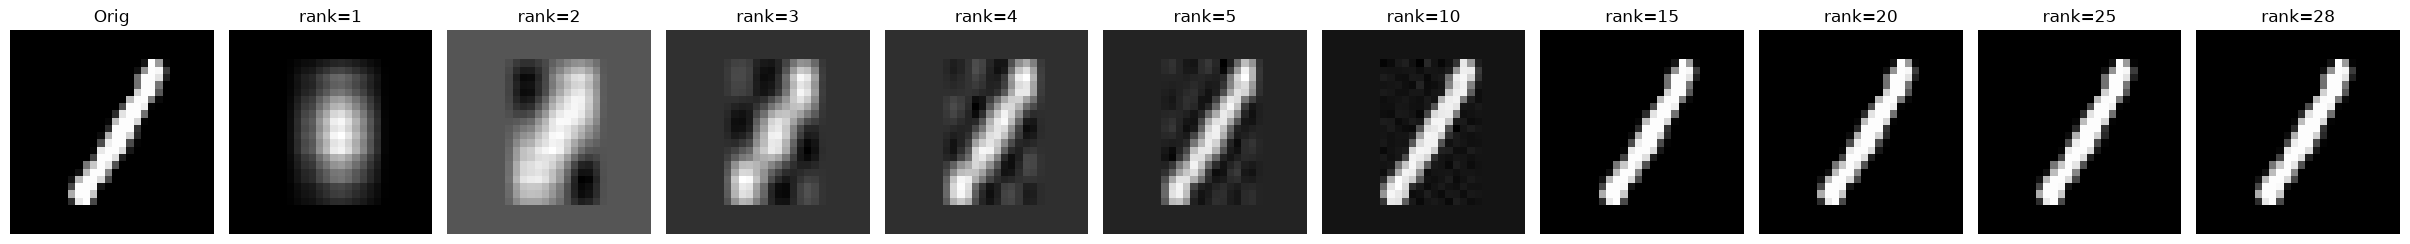

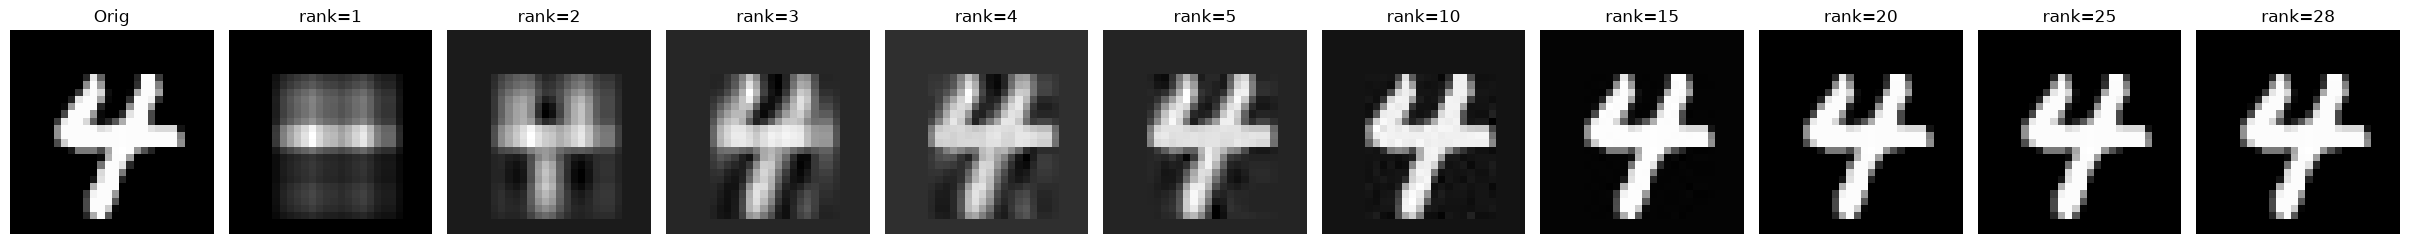

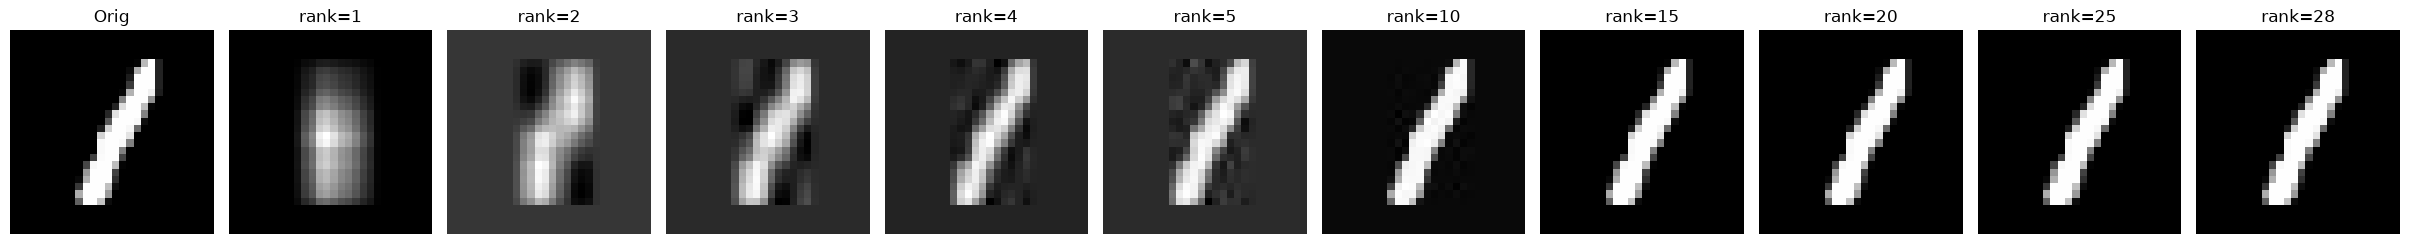

In [22]:
ranks = [1, 2, 3, 4, 5, 10, 15, 20, 25, 28]

for i, idx in enumerate(indices_tst):
    image = X_train_df.iloc[idx].values.reshape(28, 28)
    U, S, VT = np.linalg.svd(image, full_matrices=False)
    plot_rank_visual(image, U, S, VT, ranks)

Видим, что уже при ранге 4 можно понять определенную цифру

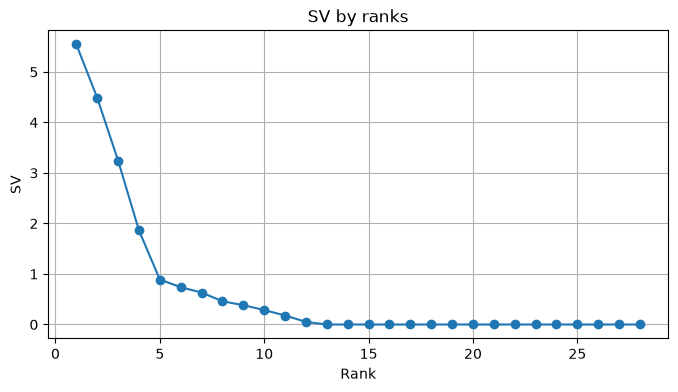

In [23]:
ranks = np.arange(1, len(S) + 1)

plt.figure(figsize=(8, 4))
plt.plot(ranks, S, marker="o")
plt.xlabel("Rank")
plt.ylabel("SV")
plt.title("SV by ranks")
plt.grid()
plt.show()

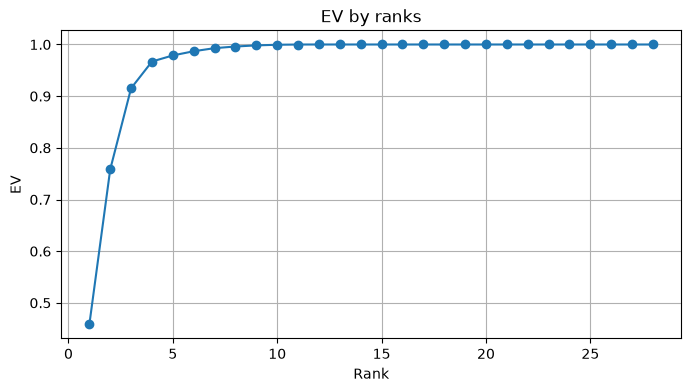

In [24]:
expl_variance = S ** 2 / np.sum(S ** 2)
plt.figure(figsize=(8, 4))
plt.plot(ranks, np.cumsum(expl_variance), marker="o")
plt.xlabel("Rank")
plt.ylabel("EV")
plt.title("EV by ranks")
plt.grid()
plt.show()

# Background detection using SVD

In [25]:
cap = cv2.VideoCapture("data/Video_008.avi")

frames = []
while True:
    ret, frame = cap.read()
    if not ret:
        break
    gray_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    frames.append(gray_frame)
cap.release()
frames = np.array(frames)
len(frames)

792

In [26]:
n_frames, height, width = frames.shape

X_vid = frames.reshape(n_frames, height * width)

U, S, VT = randomized_svd(X_vid, random_state=21, n_components=5)

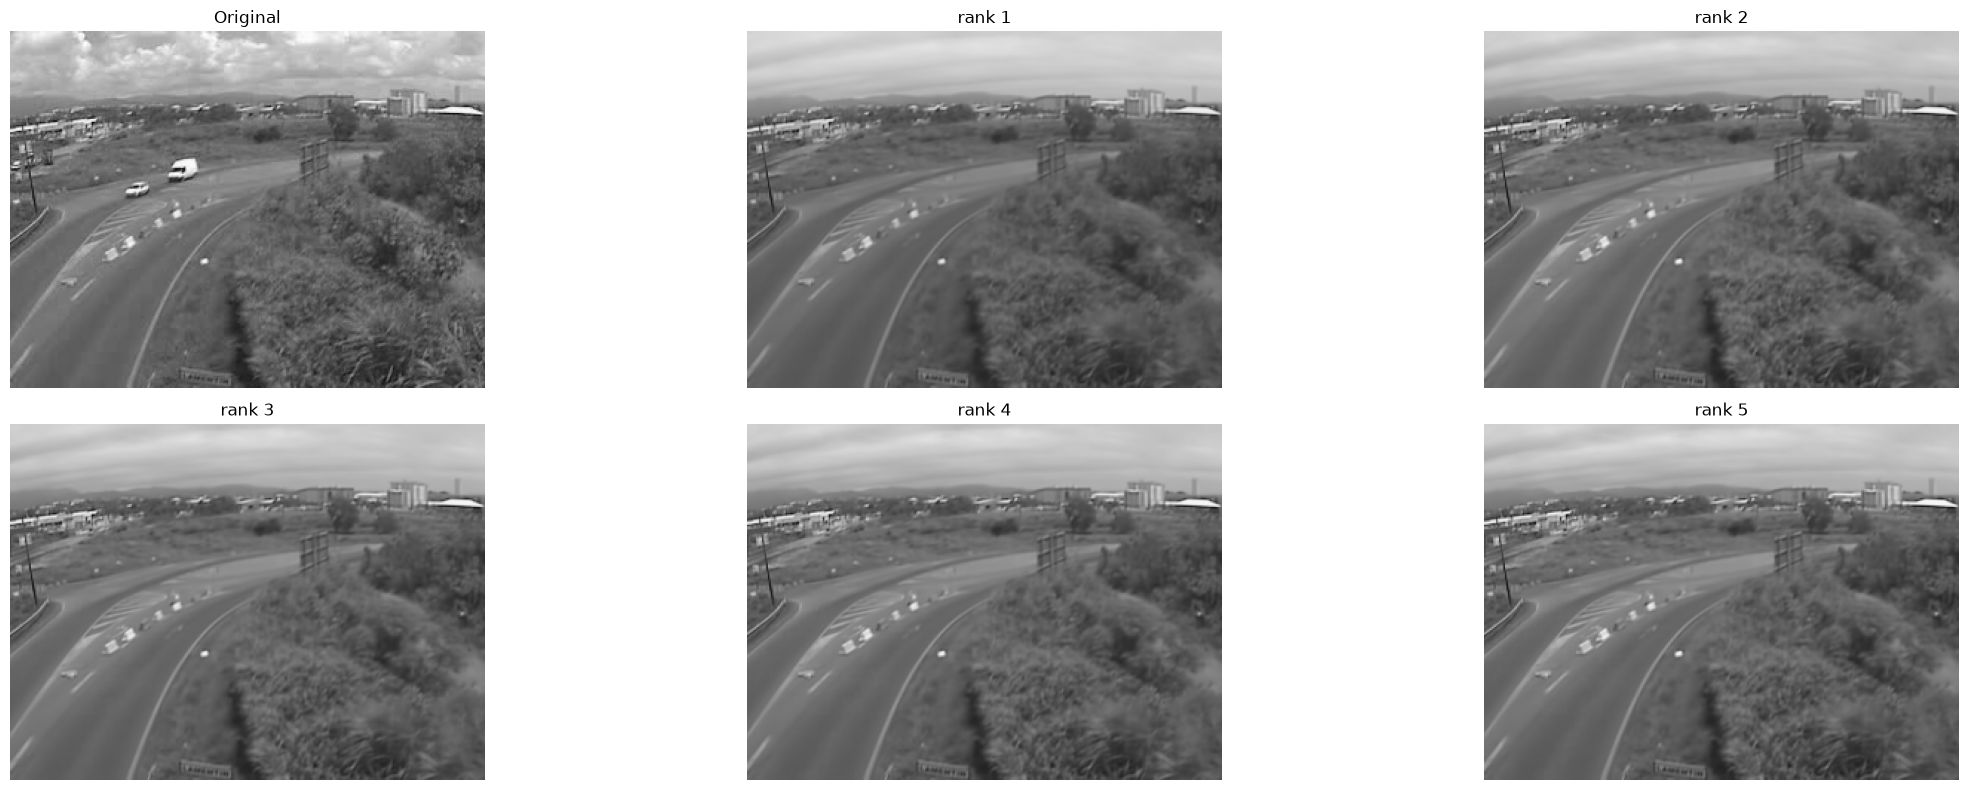

In [27]:
frame_idx = 0
ranks = np.arange(1, 6)

plt.figure(figsize=(24, 8))
plt.subplot(2, 3, 1)
plt.imshow(frames[frame_idx], cmap="gray", vmin=0, vmax=255)
plt.title("Original")
plt.axis("off")

for i, idx in enumerate(ranks):
    frame_rec = (U[frame_idx, : idx] @ np.diag(S[:idx]) @ VT[:idx, :]).reshape(height, width)
    plt.subplot(2, 3, i + 2)
    plt.imshow(frame_rec, cmap="gray", vmin=0, vmax=255)
    plt.title(f"rank {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

В целом, даже ранга 1 хватает для относительно четкого восстановления фона, хотя стоящих машин и на ранге 5 не видно

# Face expression recognition

In [20]:
def load_images_from_folder(folder, img_size=(64, 64)):
    images = []
    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_resized = cv2.resize(img, img_size)
            images.append(img_resized.flatten())
    return np.array(images)


In [21]:
sad_images = load_images_from_folder("data/sad")
happy_images = load_images_from_folder("data/happy")

all_images = np.vstack((sad_images, happy_images))
labels = np.array([0] * len(sad_images) + [1] * len(happy_images))

scaler = StandardScaler()
images_scaled = scaler.fit_transform(all_images)

pca = PCA(n_components=200)
pca.fit(images_scaled)

all_weights = pca.transform(images_scaled)

print(f"Размерность сжата с {images_scaled.shape[1]} до {all_weights.shape[1]}")

Размерность сжата с 4096 до 200


In [22]:
sad_weights = all_weights[labels == 0]
happy_weights = all_weights[labels == 1]

mean_sad = np.mean(sad_weights, axis=0)
mean_happy = np.mean(happy_weights, axis=0)

emotion_vector = mean_happy - mean_sad

In [ ]:
def edit_emotion(image_vector, pca_model, scaler_model, emotion_vec, direction='happy', strength=1.0):
    scaled_img = scaler_model.transform([image_vector])
    weights = pca_model.transform(scaled_img)
    
    if direction == 'happy':
        edited_weights = weights + strength * emotion_vec
    else:
        edited_weights = weights - strength * emotion_vec
    
    edited_scaled = pca_model.inverse_transform(edited_weights)
    edited_img = scaler_model.inverse_transform(edited_scaled)
    return edited_img.flatten()


In [36]:
edited_face_happy = edit_emotion(
    sad_images[15], 
    pca, 
    scaler, 
    emotion_vector, 
    direction='happy', 
    strength=1.5
)

edited_face_sad = edit_emotion(
    happy_images[0], 
    pca, 
    scaler, 
    emotion_vector, 
    direction='sad', 
    strength=1.5
)

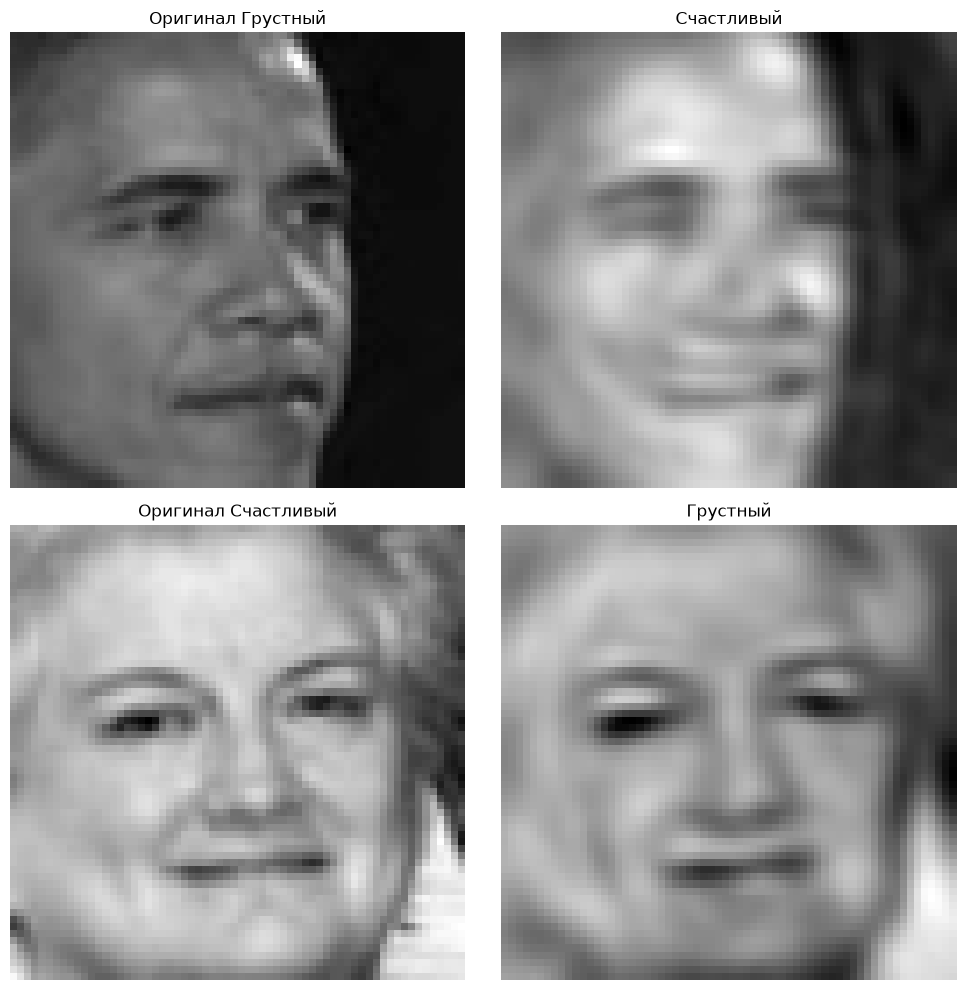

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0, 0].imshow(sad_images[15].reshape(64, 64), cmap='gray')
axes[0, 0].set_title('Оригинал Грустный')
axes[0, 0].axis('off')

axes[0, 1].imshow(edited_face_happy.reshape(64, 64), cmap='gray')
axes[0, 1].set_title('Счастливый')
axes[0, 1].axis('off')

axes[1, 0].imshow(happy_images[0].reshape(64, 64), cmap='gray')
axes[1, 0].set_title('Оригинал Счастливый')
axes[1, 0].axis('off')

axes[1, 1].imshow(edited_face_sad.reshape(64, 64), cmap='gray')
axes[1, 1].set_title('Грустный')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()